# 01 — Exploratory Data Analysis

Explore CIFAKE + GenImage datasets before training.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import random

PROCESSED = Path('../data/processed')
train_df = pd.read_csv(PROCESSED / 'train.csv')
val_df   = pd.read_csv(PROCESSED / 'val.csv')
test_df  = pd.read_csv(PROCESSED / 'test.csv')

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))

Train: 84000 | Val: 18000 | Test: 18000


## Class Distribution

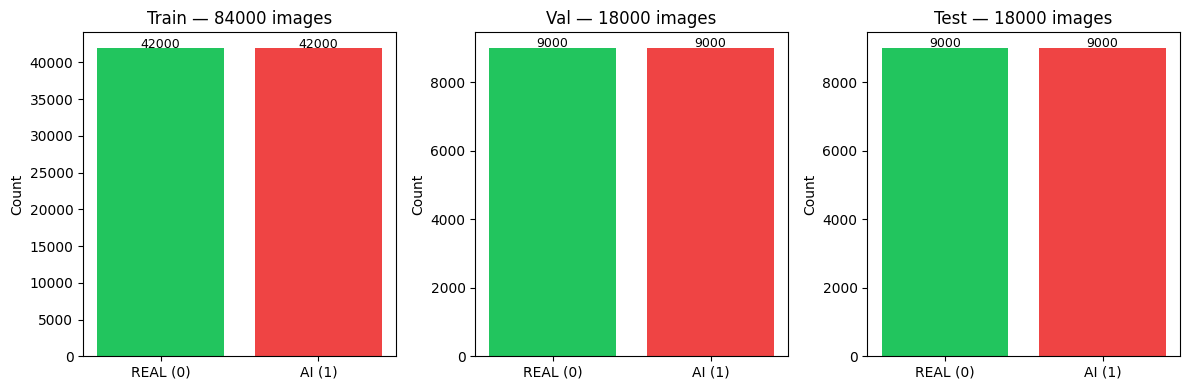

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (df, name) in zip(axes, [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['REAL (0)', 'AI (1)'], counts.values, color=['#22c55e', '#ef4444'])
    ax.set_title(f'{name} — {len(df)} images')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## Sample Images — REAL vs AI-GENERATED

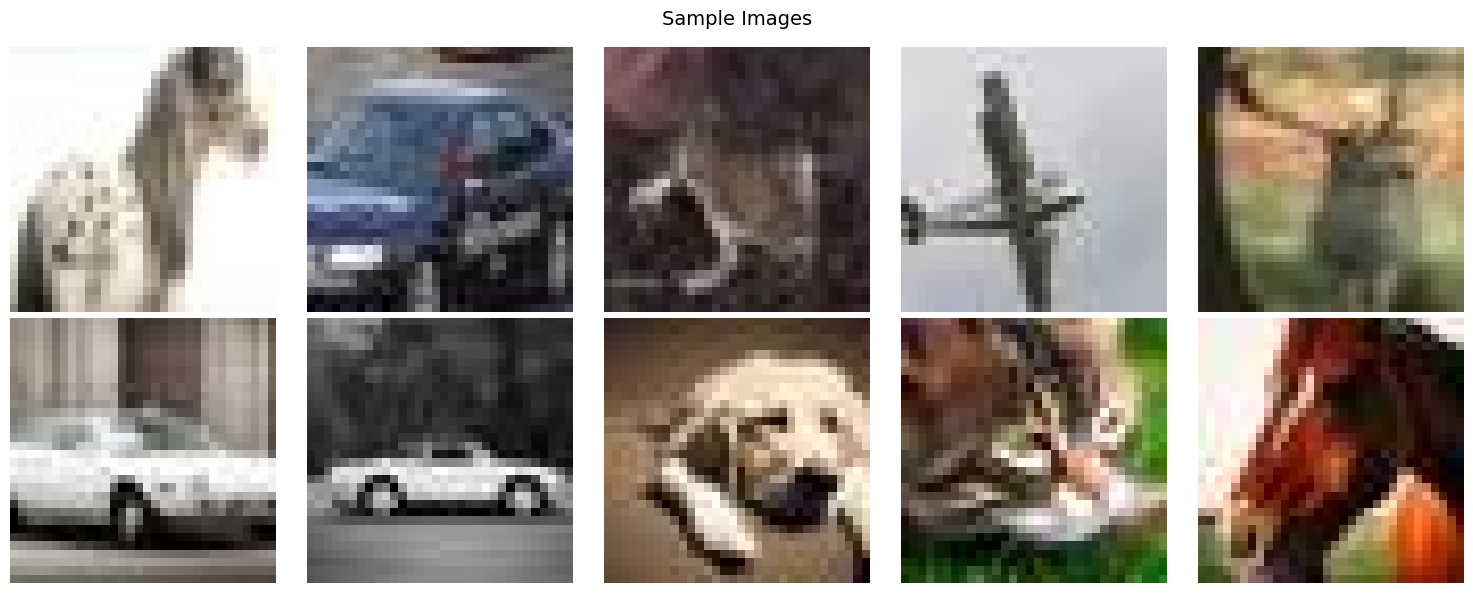

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, label in enumerate([0, 1]):
    samples = train_df[train_df['label'] == label].sample(5, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = mpimg.imread(row['filepath'])
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel('REAL' if label == 0 else 'AI', fontsize=12, rotation=0, labelpad=40)
plt.suptitle('Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Image Size Distribution

In [4]:
from PIL import Image
import numpy as np

sample = train_df.sample(min(500, len(train_df)), random_state=42)
widths, heights = [], []
for path in sample['filepath']:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

print(f'Width  — mean: {np.mean(widths):.0f}, min: {min(widths)}, max: {max(widths)}')
print(f'Height — mean: {np.mean(heights):.0f}, min: {min(heights)}, max: {max(heights)}')

Width  — mean: 32, min: 32, max: 32
Height — mean: 32, min: 32, max: 32
